In [146]:
import numpy as np 
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_blobs 
import torch 
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
import torchvision 
from torchvision import transforms
import matplotlib.pyplot as plt 

In [4]:
data = [1.0, 2.0, 3.0]
tensor = torch.Tensor(data)
print(tensor)

multidim_data = [data, data]
torch.Tensor(multidim_data).shape

tensor([1., 2., 3.])


torch.Size([2, 3])

In [ ]:
rand = torch.randn(3, 4, 4) # ex for an image with 3 color channels
rand

tensor([[[ 0.0113, -0.8978,  0.1169,  0.0779],
         [ 1.5970, -1.2807,  0.3070,  1.1441],
         [-1.0055, -0.5613,  0.6598,  1.0164],
         [ 0.7177, -0.3807,  0.1241, -1.6155]],

        [[ 0.1361, -0.5093, -0.1733,  0.1776],
         [-1.2265, -1.9801, -1.8825, -1.5470],
         [-0.6517,  1.1550,  1.3791,  0.6948],
         [ 0.4038, -1.2707, -0.1379,  2.0050]],

        [[-0.5851,  1.8676, -1.2870, -0.0326],
         [-0.4857,  1.4260, -0.0891,  0.4033],
         [ 0.2515,  0.8621,  2.1752, -0.6050],
         [ 1.5226, -0.6030, -0.5212, -0.7561]]])

### AutoGrad: 
- requires_grad=True: to track all operations on it to make Backpropagate as efficient as possible. When finishing computation we can call .backward() and have all the gradients computed automatically
- the gradient for this tensor will be accumulated into .grad attribute 
- .detach(): stop a tensor from tracking history
- torch.no_grad(): prevent tracking history (and using memory) (use when evaluating a model, as the model may have trainable parameters with required_grad = True, but evaluation we don't need the gradients)
- for any function that we provide to pytorch, it can compute the derivative at a given value

ex: calculate the derivative (with respect to x) 
$$
f(x) = 3 * (x+2)^{2}
\\
f'(x) = 6 * (x + 2)
\\
f'(1) = 18 
$$

In [ ]:
x = torch.ones(1, requires_grad=True) 
y = x + 2  # grad_fn=<AddBackward0>
z = y**2 *3 # grad_fn=<MulBackward0>

z.backward() # compute the gradient flow (backward)
x.grad # gradient 

tensor([18.])

### 1. Linear Regression

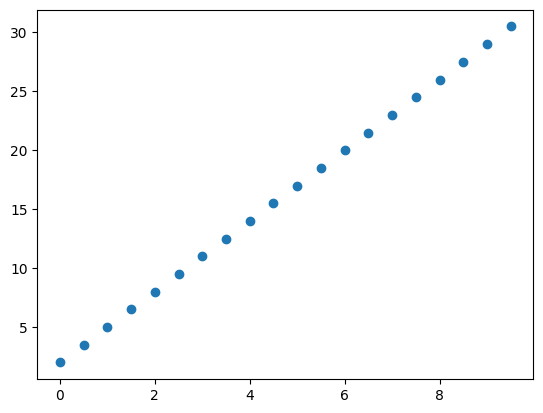

In [91]:
X = np.arange(0, 10, .5)
y = 3*X + 2

plt.plot(X, y, 'o')
plt.show()

### From scikit-learn

In [92]:
X, y = X.reshape(-1, 1), y.reshape(-1, 1)

model = LinearRegression() # from scikit-learn
model.fit(X, y)

model.coef_, model.intercept_

(array([[3.]]), array([2.]))

### Linear Regression in Pytorch 
The Pytorch Model Class has two main things to implement: 
- `__init__`: all functions are initialized here 
- super().`__init__`(): to initialize the inherited class 
- forward: how will pass the data through? 

In [93]:
torch.seed() 

class SGDRegression(nn.Module): 
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # fc1: a variable that is accessible to the entire class 
        self.fc1 = nn.Linear(1,1) # Linear(in_features, out_features): Linear layer that takes input of 1 and output of one

    def forward(self, x): # logic of network to passing data X from input to output 
        y = self.fc1(x)
        return y

model = SGDRegression()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # train to optimize the parameters of the model
EPOCHS = 5000

X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)

In [94]:
X.shape # (20, 1): (N, in_features) => N samples, each sample has (in_features) input feature 
list(model.parameters()) # two tensor with require_grad = True, as they are learnable parameters => need to compute the gradients to update them 

[Parameter containing:
 tensor([[-0.5819]], requires_grad=True),
 Parameter containing:
 tensor([-0.2119], requires_grad=True)]

In [95]:
for name, param in model.named_parameters(): # randomly initialized weights
    print(name, param)

fc1.weight Parameter containing:
tensor([[-0.5819]], requires_grad=True)
fc1.bias Parameter containing:
tensor([-0.2119], requires_grad=True)


In [96]:
for epoch in range(EPOCHS): 
    y_pred = model(X_train) # same as model.forward(X_train)
    loss = loss_fn(y_pred, y_train) 
    
    # if do not call this => model.fc1.weight.grad is NONE as default
    # compute all the gradient with respect to the loss function (for all the parmenters) 
    # and the value is stored in .grad of each tensor 
    loss.backward() 
    #print(model.fc1.weight.grad, model.fc1.bias.grad) 

    # update weights based on learning rate: w1 = w0 - learning_rate * (gradient of the loss function with respect to weight w)
    # w1 = 0.5866 - 0.01 * (-331.7656)
    optimizer.step() 
    # print(model.fc1.weight.data, model.fc1.bias.data) # weights' values after updating

    optimizer.zero_grad() # reset all the gradients
    #print(model.fc1.weight.grad, model.fc1.bias.grad) # gradients were reseted back to None

    # break => to view the result of the first epoch 

In [97]:
for name, param in model.named_parameters():
    print(name, param)

fc1.weight Parameter containing:
tensor([[3.0000]], requires_grad=True)
fc1.bias Parameter containing:
tensor([2.0000], requires_grad=True)


In [100]:
X.shape

(20, 1)

In [103]:
model(X_train)[2]

tensor([5.0000], grad_fn=<SelectBackward0>)

### 2. Classification 

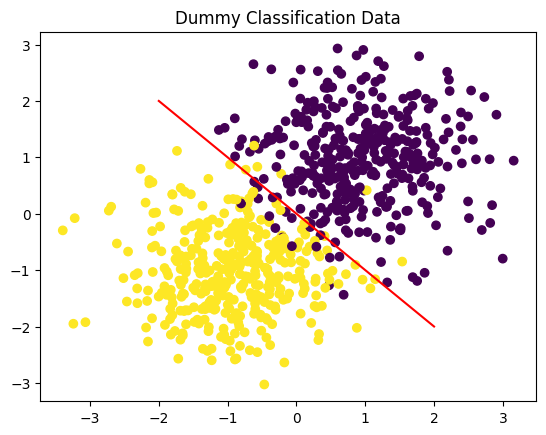

In [105]:
centers = [[1,1], [-1, -1]]
X, y = make_blobs(n_samples=750, centers=centers, cluster_std=0.8, random_state=0)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dummy Classification Data")
plt.plot([-2, 2], [2, -2], 'r')
plt.show()

y = y.reshape(-1, 1)

In [106]:
torch.seed() 

class LogisticRegression(nn.Module): 
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.fc1 = nn.Linear(2, 1) # X has 2 features for each sample, output only 1/0 => 1 value 

    def forward(self, x): 
        z = self.fc1(x) 
        y = torch.sigmoid(z)

        return y 
    
model = LogisticRegression() 
loss_fn = torch.nn.BCELoss() 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
EPOCHS = 5000

X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)


In [107]:
for epoch in range(EPOCHS): 
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    loss.backward() 
    optimizer.step()
    optimizer.zero_grad() 

In [142]:
with torch.inference_mode(): # no need to compute parameters
    y_final_pred = model(X_train)

y_final_pred = (y_final_pred > 0.5).int()
y_final_pred[:5]

tensor([[0],
        [0],
        [0],
        [1],
        [0]], dtype=torch.int32)

In [ ]:
# accuracy 
torch.mean((y_final_pred == y_train).float()) # 96% 

tensor(0.9680)

### 3. MNIST

In [148]:
train = torchvision.datasets.MNIST("../data", train=True, download=True,
                                   transform=transforms.Compose([ # convert array to tensor 
                                       transforms.ToTensor() 
                                   ]))

test = torchvision.datasets.MNIST("../data", train=False, download=True,
                                   transform=transforms.Compose([ # convert array to tensor 
                                       transforms.ToTensor() 
                                   ]))

print(train)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.68MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 307kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.99MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )


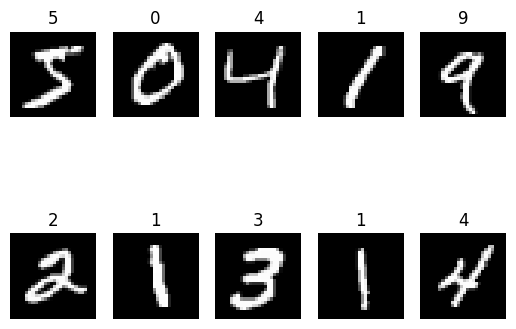

In [163]:
counter = 1
for image, label in train: 
    # print(image.shape) # [1, 28, 28]: 1 channel, 28x28 pixels 
    image = image.squeeze() # [28, 28]: remote dimension with 1

    plt.subplot(2, 5, counter)
    plt.axis('off')
    plt.imshow(image, cmap="gray")
    plt.title(label)
    
    counter += 1
    if(counter > 10): 
        break

### Neural Network Considerations: 
- Batch size: how many samples do we want to feed through the network at every step? 
    - Too large: we won't be able to fit our data in Memory 
    - Too small: the model won't see a wide enough range of data everytime to generalize properly 
- Optimizer: How will be descend our Cost Curve? The most common optimizer is Adam but different problems can benefit from a different optimzer 
- Loss Function: How do we calculate error? This is highly dependent on the problem! regression or classification? how many classes?...
- Epochs: how many passes do we want through the entire data? 
    - Too few: the model will not learn the weights (underfitting)
    - Too many: the model will memorize the data (overfitting)
- LR: how quick do we want to learn? 
    - Too fast: will be unstable 
    - Too slow: will cause training to take more time than necessary 

In [165]:
BATCH_SIZE = 128 
LOSS = nn.CrossEntropyLoss()
LR = 0.008 
EPOCHS = 5

DataLoader: to do MiniBatches => wrap the train and test data with DataLoader 
ex: BATCH_SIZE = 128  
-> DataLoader return images in the shapes of [128 x 1 x 28 x 28] at a time rather than [1 x 1 x 28 x 28]

Shapes for images: [Batch size x Number of channels X Image Height x Image Width]

In [ ]:
trainset = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, shuffle=True) # default NUM_WORKERS = 0
testset = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE, shuffle=True) # default NUM_WORKERS = 0

for images, labels in trainset: 
    print(images.shape) # [N, C, H, W]
    print(labels)
    break

torch.Size([128, 1, 28, 28])
tensor([9, 4, 3, 3, 0, 4, 5, 5, 0, 2, 9, 1, 3, 8, 7, 0, 0, 1, 8, 1, 4, 6, 2, 1,
        8, 3, 8, 9, 1, 5, 2, 0, 9, 0, 5, 0, 0, 9, 3, 7, 0, 6, 4, 2, 0, 1, 0, 6,
        3, 2, 2, 3, 1, 8, 3, 2, 7, 2, 7, 0, 9, 4, 9, 8, 7, 7, 6, 4, 4, 9, 6, 7,
        3, 5, 0, 1, 2, 1, 8, 1, 6, 9, 4, 1, 1, 6, 0, 2, 6, 2, 4, 2, 4, 3, 8, 5,
        3, 2, 0, 5, 0, 3, 3, 9, 1, 4, 3, 2, 5, 5, 4, 2, 8, 6, 5, 5, 7, 4, 5, 6,
        8, 2, 7, 1, 2, 6, 2, 1])


- BCE Loss: Expects 1 output where > 0.5 is 1 and < 0.5 is 0
- CE Loss: expects 2 outputs where the first output is the prob of 1 and the second is the prob of 0

In Pytorch, The Cross Entropy Loss expects **LOGITS**

In [ ]:
class FCNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
        self.fc1 = nn.Linear(1*28*28, 64) # each image has size 1 channelx28x28, 10 classes output 
        self.fc2 = nn.Linear(64, 128) 
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)


    def forward(self, x):
        # x.flatten(1): start to flatten from the first dimension, x.flatten() flatten everything
        # same as: batch_size = x.shape[0], x = x.reshape(batch_size, -1)
        x = x.flatten(1) 
        x = F.relu(self.fc1(x)) # deeper and deeper neural network when stacking layers over each other
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x) # the output will not have activation cause pytorch will add the softmax to it in the loss function
        # print(x.shape, logits.shape)

        # (input, dim): after softmax on the dimension number 1 of x, as logits.shape = [128, 10]
        # but In Pytorch, The Cross Entropy Loss expects **LOGITS** (raw outputs) => no need softmax here
        # x = F.log_softmax(x, 1) 
        return x


Training Loop

In [202]:
model = FCNet()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS): 
    print(f"Training epoch {epoch + 1}")
    losses_hist = []

    for images, labels in trainset: 
        # print(images.shape)
        # print(labels)

        forward_output = model(images)
        loss = LOSS(forward_output, labels) # (predicted, true y values)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

        # print(loss) # NllLoss: negative log likelihood loss
        losses_hist.append(loss.item()) # store loss each batch 
        

    print(f"Loss: {np.mean(losses_hist)}") # the everage loss for this epoch 
    

Training epoch 1
Loss: 0.2862446338160714
Training epoch 2
Loss: 0.1371706898913963
Training epoch 3
Loss: 0.1089793144901996
Training epoch 4
Loss: 0.0932921425425517
Training epoch 5
Loss: 0.08790871338186058


### Model Evaluation 

1. model.eval(): change the model into evaluation mode
    - off dropout layers (if has)
    - change to use running statistics of BatchNorm (if has), which are accumulated during training instead of mean/var from the current batch. Because when training the model use mean/var of the current batch 
    - still keep gradient computation
2. with torch.no_grad():
    - stop gradient tracking => save memory
    - no need to compute gradients => speed up forward pass 
    - no effect on dropout or BatchNorm 

3. with torch.inference_mode(): more optimized than torch.no_grad()



In [203]:
correct = 0
total = 0

model.eval() # c:  (dropout off, batchnorm fixed)

with torch.inference_mode():
    for images, labels in testset: 
        forward_output = model(images)

        #print(forward_output.shape)

        for idx, i in enumerate(forward_output):
            prediction = torch.argmax(i) # i is the prediction vector with 10 items
            if prediction == labels[idx]: 
                correct += 1
            total += 1
    
print(f"Accuracy: {round(correct/total, 2)}")

Accuracy: 0.96


### Recap
We have 96% accuracy

### GPU Acceleration
- In pytorch, a GPU is indicated by "cuda" and to move a model or tensor to the gpu, we use: .to("cuda"). But all tensors must be on the same device before an operation can be made 
- More complex acceleration: 
    - DataParallel
    - Distributed DataParallel

In [ ]:
!nvidia-smi # to view all GPU devices 

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [205]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = FCNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS): 
    print(f"Training epoch {epoch + 1}")
    losses_hist = []

    for images, labels in trainset: 
        # print(images.shape)
        # print(labels)

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        forward_output = model(images)
        loss = LOSS(forward_output, labels) # (predicted, true y values)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

        # print(loss) # NllLoss: negative log likelihood loss
        losses_hist.append(loss.item()) # store loss each batch 
        

    print(f"Loss: {np.mean(losses_hist)}") # the everage loss for this epoch 
    


Training epoch 1
Loss: 0.28100646739956664
Training epoch 2
Loss: 0.13498443334516305
Training epoch 3
Loss: 0.11012563388596085
Training epoch 4
Loss: 0.09610223894450329
Training epoch 5
Loss: 0.08543724495707068


Adding the validation loop 

In [207]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10

trainning_avg_losses = []
validation_avg_losses = []

model = FCNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS): 
    print(f"Training epoch {epoch + 1}")
    batch_training_losses = []
    batch_validation_losses = []

    ### TRAINING
    for images, labels in trainset: 
        # print(images.shape)
        # print(labels)

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        forward_output = model(images)
        loss = LOSS(forward_output, labels) # (predicted, true y values)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

        # print(loss) # NllLoss: negative log likelihood loss
        batch_training_losses.append(loss.item()) # store loss each batch 

    ### EVALUATING
    model.eval() # set to evaluation mode 
    for images, labels in testset: 
        with torch.no_grad(): # 
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            forward_output = model(images)
            loss = LOSS(forward_output, labels)

            batch_validation_losses.append(loss.item())
        
    epoch_training_losses = np.mean(batch_training_losses)
    epoch_validation_losses = np.mean(batch_validation_losses)

    trainning_avg_losses.append(epoch_training_losses)
    validation_avg_losses.append(epoch_validation_losses)

    print(f"Training Loss: {epoch_training_losses}") # the everage loss for this epoch 
    print(f"Validation Loss: {epoch_validation_losses}") # the everage loss for this epoch 


Training epoch 1
Training Loss: 0.27971702964225814
Validation Loss: 0.14637496077184436
Training epoch 2
Training Loss: 0.13267539931671707
Validation Loss: 0.13314081888787355
Training epoch 3
Training Loss: 0.10578212386040863
Validation Loss: 0.12475785351346565
Training epoch 4
Training Loss: 0.094628075149649
Validation Loss: 0.10208280014369307
Training epoch 5
Training Loss: 0.08377360268088896
Validation Loss: 0.11398741901893451
Training epoch 6
Training Loss: 0.0777131092391098
Validation Loss: 0.14141049165325828
Training epoch 7
Training Loss: 0.07518215017936337
Validation Loss: 0.13808805959982962
Training epoch 8
Training Loss: 0.0669690109000031
Validation Loss: 0.11730241388836994
Training epoch 9
Training Loss: 0.06383318191608672
Validation Loss: 0.10655155437821641
Training epoch 10
Training Loss: 0.06218399058209299
Validation Loss: 0.16695394589789683


### Overfitting 
The training loss continues to decrease but the valuation loss is stagnant or even worse and worse 
=> overfitting 

Maybe at this step (to be discussed later): try to save the model with the best loss and stop early if there is no improvement in evaluation 

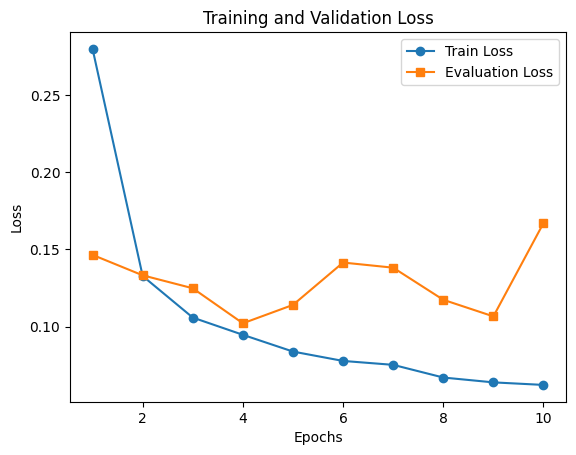

In [209]:
epochs = range(1, EPOCHS + 1)
plt.plot(epochs, trainning_avg_losses, label="Train Loss", marker='o')
plt.plot(epochs, validation_avg_losses, label="Evaluation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()